
# AI-Based Intrusion Detection System (IDS) for IoT Networks

This notebook implements a **hybrid Intrusion Detection System (IDS)** for IoT networks using both **supervised** and **unsupervised** learning methods.  
The goal is to detect potential network intrusions in real time by analyzing traffic data.

---


### Code Execution
This cell executes a part of the IDS workflow.

In [ ]:
!pip install kaggle


### Importing Required Libraries
We begin by importing the necessary Python libraries used for data preprocessing, visualization, and model training.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot")

print("Path to dataset files:", path)

100%|██████████| 1.63G/1.63G [00:45<00:00, 38.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/versions/5


### Importing Required Libraries
We begin by importing the necessary Python libraries used for data preprocessing, visualization, and model training.

In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/versions/5/"

print("Files inside subfolder:", os.listdir(dataset_path))

Files inside subfolder: ['Edge_IIoTset__DatasetFL.pdf', 'Readme.txt', 'Edge-IIoTset dataset']


### Load Dataset
We load the IoT dataset containing network traffic samples for training the IDS.

In [ ]:
import pandas as pd
import os

ml_path = dataset_path + "/Edge-IIoTset dataset/Selected dataset for ML and DL"
csv_file = "ML-EdgeIIoT-dataset.csv"

df = pd.read_csv(os.path.join(ml_path, csv_file))


print("Dataset shape:", df.shape)
display(df.head())
df.info()

/tmp/ipython-input-1723028481.py:7: DtypeWarning: Columns (3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(ml_path, csv_file))


Dataset shape: (157800, 63)


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
2,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
3,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
4,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157800 entries, 0 to 157799
Data columns (total 63 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   frame.time                 157800 non-null  object 
 1   ip.src_host                157800 non-null  object 
 2   ip.dst_host                157800 non-null  object 
 3   arp.dst.proto_ipv4         157800 non-null  object 
 4   arp.opcode                 157800 non-null  float64
 5   arp.hw.size                157800 non-null  float64
 6   arp.src.proto_ipv4         157800 non-null  object 
 7   icmp.checksum              157800 non-null  float64
 8   icmp.seq_le                157800 non-null  float64
 9   icmp.transmit_timestamp    157800 non-null  float64
 10  icmp.unused                157800 non-null  float64
 11  http.file_data             157800 non-null  object 
 12  http.content_length        157800 non-null  float64
 13  http.request.uri.query     15

#### Visualize Class Distribution

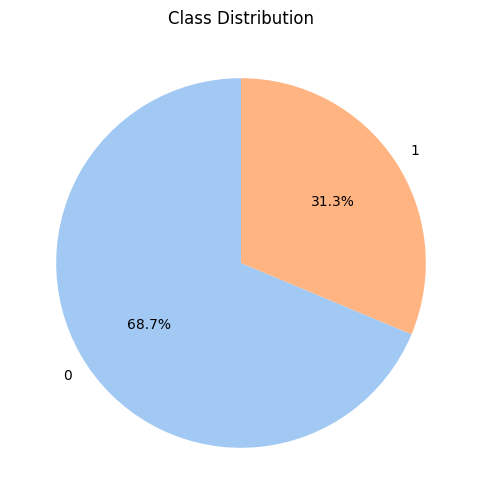

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

label_col = 'label' if 'label' in df.columns else df.columns[-1]
plt.figure(figsize=(6,6))
df[label_col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Class Distribution')
plt.ylabel('')
plt.show()


### Importing Required Libraries
We begin by importing the necessary Python libraries used for data preprocessing, visualization, and model training.

In [ ]:
import pandas as pd
import numpy as np
import sklearn, numpy, lightgbm
print(sklearn.__version__, numpy.__version__)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib

1.6.1 2.0.2


In [ ]:

print("Initial shape:", df.shape)

Initial shape: (157800, 47)


### Drop Irrelevant Columns
These columns do not affect the detection of an attack.


1.   ip host (src and dst) can be easily spoofed.
2.   http.file_data is highly variable and can be encrypted, making it an inconsistent indicator.
3. can be manipulated easily and do not reliably differentiate between benign and malicious requests.
4. tcp options are configurations not relevant to attacks.
5. tcp payload is encrypted.
6. mqtt is a constant.
7. dns name is found in both normal and malicious data.

In [ ]:

drop_cols = [
    "ip.src_host", "ip.dst_host", "http.file_data", "http.request.full_uri",
    "http.referer", "http.request.uri.query", "tcp.options", "tcp.payload",
    "mqtt.msg", "mqtt.protoname", "mqtt.topic", "dns.qry.name"
]
df = df.drop(columns=drop_cols, errors="ignore")
print("After dropping columns:", df.shape)

After dropping columns: (157800, 47)


### Identify Categorical Data

In [ ]:

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "Attack_type"]
print("Categorical columns to encode:", cat_cols)

Categorical columns to encode: []


In [ ]:
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

Categorical features are columns that contain textual or symbolic values instead of numbers.

### Data Cleaning
add 0 to null values

In [ ]:

df = df.replace("?", np.nan)
df = df.fillna(0)

### Split features and target labels for model training.

In [ ]:
# Create a new binary column for Botnet attacks
df['Botnet_attack'] = df['Attack_type'].apply(lambda x: 1 if isinstance(x, str) and x.startswith('DDoS_') else 0)

In [ ]:
X = df.drop(columns=["Attack_label", "Attack_type", "Botnet_attack"], errors="ignore")
y = df["Botnet_attack"]  # Use the new binary column as the target
print("Features shape:", X.shape)
print("Labels shape:", y.shape)

print(X.head())
print(y.head())

Features shape: (157800, 44)
Labels shape: (157800,)
   frame.time  arp.dst.proto_ipv4  arp.opcode  arp.hw.size  \
0      153888                   1         0.0          0.0   
1      153888                   1         0.0          0.0   
2      153888                   1         0.0          0.0   
3      153888                   1         0.0          0.0   
4      153888                   1         0.0          0.0   

   arp.src.proto_ipv4  icmp.checksum  icmp.transmit_timestamp  icmp.unused  \
0                   1            0.0                      0.0          0.0   
1                   1            0.0                      0.0          0.0   
2                   1            0.0                      0.0          0.0   
3                   1            0.0                      0.0          0.0   
4                   1            0.0                      0.0          0.0   

   http.content_length  http.request.method  ...  mqtt.conflags  \
0                  0.0                

### Splitting Dataset into Train and Test Sets
We divide the dataset into training and testing subsets to evaluate our model performance on unseen data.

### Data Splitting
Split dataset into training and test sets for supervised model evaluation.

In [ ]:
# dont use stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

### Model Training
Normalize feature values using StandardScaler for better model performance.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("X_train_scaled shape:", X_train_scaled.shape)


X_train_scaled shape: (110460, 44)


In [ ]:

joblib.dump(scaler, "scaler.pkl")
print(" Preprocessing complete. Scaler saved as scaler.pkl")

 Preprocessing complete. Scaler saved as scaler.pkl


### Training using Random Forest

RandomForest Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     32564
           1       1.00      1.00      1.00     14776

    accuracy                           1.00     47340
   macro avg       1.00      1.00      1.00     47340
weighted avg       1.00      1.00      1.00     47340



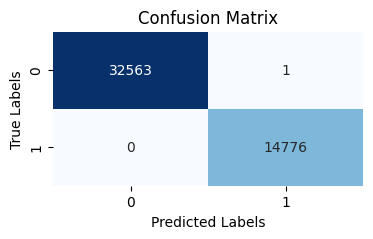

 RandomForest model saved as randomforest_ids_model.pkl


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)



rf.fit(X_train_scaled, y_train)


y_pred = rf.predict(X_test_scaled)



accuracy = accuracy_score(y_test, y_pred) * 100  # convert to percentage
print(f"RandomForest Accuracy: {accuracy:.2f}%")

print("\nClassification Report:\n", classification_report(y_test, y_pred))
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

import joblib
joblib.dump(rf, "randomforest_ids_model.pkl")
print(" RandomForest model saved as randomforest_ids_model.pkl")


*Model was overfitted due to leakage.*
---


### Model Training
Train machine learning models to classify network traffic as benign or malicious.

Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[200]	train's binary_logloss: 4.865e-05	test's binary_logloss: 4.915e-05
 LightGBM Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     32564
           1       1.00      1.00      1.00     14776

    accuracy                           1.00     47340
   macro avg       1.00      1.00      1.00     47340
weighted avg       1.00      1.00      1.00     47340



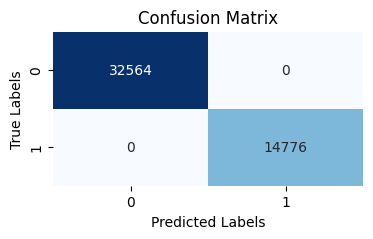

 LightGBM model saved as lightgbm_ids_model.txt


In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

lgb_train = lgb.Dataset(X_train_scaled, label=y_train)
lgb_test = lgb.Dataset(X_test_scaled, label=y_test, reference=lgb_train)


params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}



lgbm_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_train, lgb_test],
    valid_names=['train','test'],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=True)]
)


y_pred_prob = lgbm_model.predict(X_test_scaled, num_iteration=lgbm_model.best_iteration)
y_pred = (y_pred_prob > 0.5).astype(int)  # convert probabilities to 0/1


accuracy = accuracy_score(y_test, y_pred)
print(f" LightGBM Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

lgbm_model.save_model("lightgbm_ids_model.txt")
print(" LightGBM model saved as lightgbm_ids_model.txt")

Some features in the Edge-IIoTset dataset are directly or almost perfectly correlated with the attack label.<br>
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) -This splits rows randomly.

For IoT/IIoT data, multiple packets belong to the same session/device.

Random splitting caused packets from the same session to appear in both train and test.


In [ ]:
print("Train class distribution:\n", y_train.value_counts())
print("Test class distribution:\n", y_test.value_counts())


Train class distribution:
 Botnet_attack
0    75840
1    34620
Name: count, dtype: int64
Test class distribution:
 Botnet_attack
0    32564
1    14776
Name: count, dtype: int64


trying to remove leaks from the dataset

Features shape after leak removal: (157800, 44)
Labels shape: (157800,)


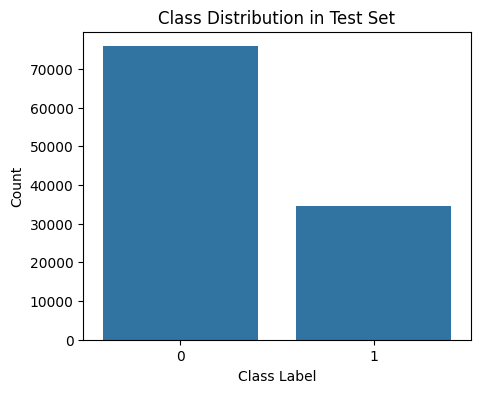

In [ ]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib

drop_cols = [
    "ip.src_host", "ip.dst_host", "http.file_data", "http.request.full_uri",
    "http.referer", "http.request.uri.query", "tcp.options", "tcp.payload",
    "mqtt.msg", "mqtt.protoname", "mqtt.topic", "dns.qry.name"
]
df = df.drop(columns=drop_cols, errors="ignore")

leak_cols = ["mbtcp.trans_id", "icmp.seq_le", "tcp.seq", "tcp.ack", "dns.qry.qu"]
df = df.drop(columns=[c for c in leak_cols if c in df.columns], errors="ignore")

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "Attack_type"]

high_cardinality_cols = ["frame.time"]  # too many unique values → could leak info
cat_cols = [c for c in cat_cols if c not in high_cardinality_cols]

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

df = df.replace("?", np.nan)
df = df.fillna(0)

X = df.drop(columns=["Attack_label", "Attack_type", "Botnet_attack"], errors="ignore")
# Attack type, focus on ddos
y = df["Botnet_attack"]

print("Features shape after leak removal:", X.shape)
print("Labels shape:", y.shape)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc

# Class Distribution Histogram
plt.figure(figsize=(5, 4))
sns.countplot(x=y_train)
plt.title("Class Distribution in Test Set")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()


### Data Splitting
Split dataset into training and test sets for supervised model evaluation.

In [ ]:

from sklearn.model_selection import GroupShuffleSplit

group_col = "tcp.srcport" if "tcp.srcport" in df.columns else None

if group_col:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=df[group_col]))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Overlapping rows between train and test:", len(set(X_train.index) & set(X_test.index)))

df.columns


Train shape: (114185, 44)
Test shape: (43615, 44)
Overlapping rows between train and test: 0


Index(['frame.time', 'arp.dst.proto_ipv4', 'arp.opcode', 'arp.hw.size',
       'arp.src.proto_ipv4', 'icmp.checksum', 'icmp.transmit_timestamp',
       'icmp.unused', 'http.content_length', 'http.request.method',
       'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack_raw',
       'tcp.checksum', 'tcp.connection.fin', 'tcp.connection.rst',
       'tcp.connection.syn', 'tcp.connection.synack', 'tcp.dstport',
       'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.srcport', 'udp.port',
       'udp.stream', 'udp.time_delta', 'dns.qry.name.len', 'dns.qry.type',
       'dns.retransmission', 'dns.retransmit_request',
       'dns.retransmit_request_in', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len',
       'mqtt.msg_decoded_as', 'mqtt.msgtype', 'mqtt.proto_len',
       'mqtt.topic_len', 'mqtt.ver', 'mbtcp.len', 'mbtcp.unit_id',
       'Attack_label', 'Attack_type', 'Botnet_attack'],
      dtype='object')

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler_ids.pkl")
print("Scaler saved")


Scaler saved


 RandomForest Accuracy: 100.00%
 RandomForest Balanced Accuracy: 100.00%
 RandomForest F1-Score: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     35780
           1       1.00      1.00      1.00      7835

    accuracy                           1.00     43615
   macro avg       1.00      1.00      1.00     43615
weighted avg       1.00      1.00      1.00     43615



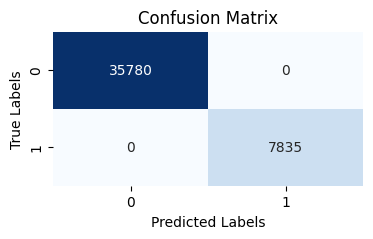

RandomForest model saved


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # handle imbalance
)

rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred) * 100
balanced_acc = balanced_accuracy_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100

print(f" RandomForest Accuracy: {accuracy:.2f}%")
print(f" RandomForest Balanced Accuracy: {balanced_acc:.2f}%")
print(f" RandomForest F1-Score: {f1:.2f}%\n")

print("Classification Report:\n", classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

joblib.dump(rf, "randomforest_ids_model_balanced.pkl")
print("RandomForest model saved")


Dropped identifiable text/raw columns <br>

Handled high-cardinality features (frame.time)

Group-based train-test split - Ensures packets from the same session/device don’t appear in both train and test → mimics real-world deployment.

 RandomForest Accuracy: 100.00%
 RandomForest Balanced Accuracy: 100.00%
 RandomForest F1-Score: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     35780
           1       1.00      1.00      1.00      7835

    accuracy                           1.00     43615
   macro avg       1.00      1.00      1.00     43615
weighted avg       1.00      1.00      1.00     43615



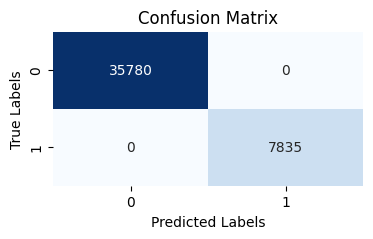

✅ RandomForest model saved as randomforest_ids_model_balanced.pkl


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score
import joblib

rf = RandomForestClassifier(
    n_estimators=200,      # more trees for stability
    max_depth=15,          # prevent overfitting
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred) * 100
balanced_acc = balanced_accuracy_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100

print(f" RandomForest Accuracy: {accuracy:.2f}%")
print(f" RandomForest Balanced Accuracy: {balanced_acc:.2f}%")
print(f" RandomForest F1-Score: {f1:.2f}%\n")

print("Classification Report:\n", classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

joblib.dump(rf, "randomforest_ids_model_balanced.pkl")
print("✅ RandomForest model saved as randomforest_ids_model_balanced.pkl")


more tress(200),

 depth control,

  class imbalace handling( prevents bias towards the majority class)

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[151]	train's binary_logloss: 0.000424165	test's binary_logloss: 0.00240287
 LightGBM Accuracy: 99.89%
 LightGBM Balanced Accuracy: 99.93%
 LightGBM F1-Score: 99.69%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     35780
           1       0.99      1.00      1.00      7835

    accuracy                           1.00     43615
   macro avg       1.00      1.00      1.00     43615
weighted avg       1.00      1.00      1.00     43615



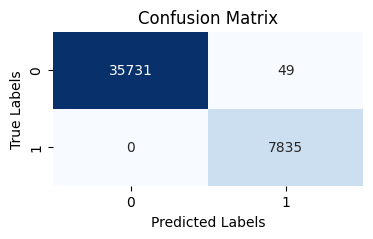

LightGBM model saved


In [ ]:

import lightgbm as lgb

lgb_train = lgb.Dataset(X_train_scaled, label=y_train)
lgb_test = lgb.Dataset(X_test_scaled, label=y_test, reference=lgb_train)

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

lgbm_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_train, lgb_test],
    valid_names=['train','test'],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=True)]
)

y_pred_prob = lgbm_model.predict(X_test_scaled, num_iteration=lgbm_model.best_iteration)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred) * 100
balanced_acc = balanced_accuracy_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100

print(f" LightGBM Accuracy: {accuracy:.2f}%")
print(f" LightGBM Balanced Accuracy: {balanced_acc:.2f}%")
print(f" LightGBM F1-Score: {f1:.2f}%\n")

print("Classification Report:\n", classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

lgbm_model.save_model("lightgbm_ids_model_balanced.txt")
print("LightGBM model saved")


no leakage<br>
balance matrix<br>
early stopping- prevents overfitting<br>
Hyperparameter Tuning- helps generalizw well


### Unsupervised Mode training
using isolation forest

Isolation Forest Test F1-score: 0.17%
Balanced Accuracy: 39.52%


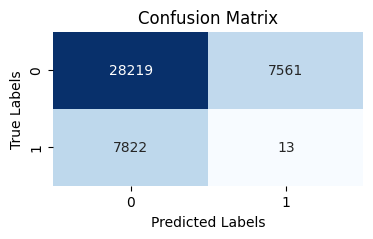

Isolation Forest model saved


In [ ]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.1,  # approximate anomaly fraction
    random_state=42,
    n_jobs=-1
)

X_train_normal = X_train_scaled[y_train==0]
iso_forest.fit(X_train_normal)

y_anomaly = iso_forest.predict(X_test_scaled)
y_anomaly = np.where(y_anomaly == -1, 1, 0)  # convert to 0/1 labels

print(f"Isolation Forest Test F1-score: {f1_score(y_test, y_anomaly)*100:.2f}%")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_anomaly)*100:.2f}%")

joblib.dump(iso_forest, "isolation_forest_model.pkl")

# Create confusion matrix
cm = confusion_matrix(y_test, y_anomaly)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


print("Isolation Forest model saved")


raw text- irrelevant<br>
high leakage<br>
missing values no scaling<br>


### Model Selection and Training
We train the model here. Since this is a hybrid IDS (supervised + unsupervised), we may use algorithms like RandomForest, SVM, or Isolation Forest for anomaly detection.


 Isolation Forest Test Accuracy: 39.68%
 Isolation Forest Balanced Accuracy: 26.17%
 Isolation Forest F1-Score: 2.94%

Isolation Forest Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.47      0.56     35780
           1       0.02      0.05      0.03      7835

    accuracy                           0.40     43615
   macro avg       0.36      0.26      0.30     43615
weighted avg       0.57      0.40      0.47     43615



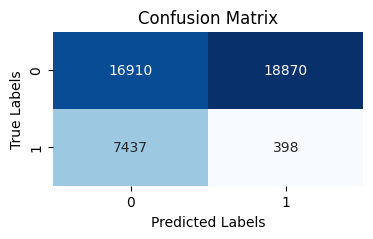

Isolation Forest model saved.


In [ ]:

iso = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=0.2,  # adjust based on expected anomaly ratio
    random_state=42
)
iso.fit(X_train_scaled)
y_iso_pred = iso.predict(X_test_scaled)
y_iso = np.where(y_iso_pred == 1, 0, 1)  # convert to 0=Normal, 1=Attack

accuracy_iso = accuracy_score(y_test, y_iso) * 100
balanced_acc_iso = balanced_accuracy_score(y_test, y_iso) * 100
f1_iso = f1_score(y_test, y_iso) * 100
print(f"\n Isolation Forest Test Accuracy: {accuracy_iso:.2f}%")
print(f" Isolation Forest Balanced Accuracy: {balanced_acc_iso:.2f}%")
print(f" Isolation Forest F1-Score: {f1_iso:.2f}%\n")

print("Isolation Forest Classification Report:\n", classification_report(y_test, y_iso))
# Create confusion matrix
cm = confusion_matrix(y_test, y_iso)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

joblib.dump(iso, "isolationforest_ids_model.pkl")
print("Isolation Forest model saved.")


training on full data-<br>
increased trees<br>
scaling<br>
label mapping

 Hybrid IDS Accuracy: 62.90%
 Hybrid IDS Balanced Accuracy: 77.39%
 Hybrid IDS F1-Score: 49.20%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.55      0.71     35780
           1       0.33      1.00      0.49      7835

    accuracy                           0.63     43615
   macro avg       0.66      0.77      0.60     43615
weighted avg       0.88      0.63      0.67     43615



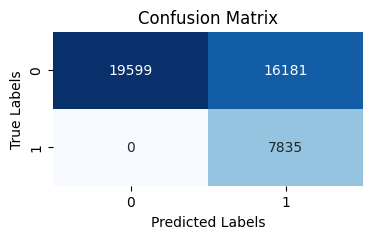

 Hybrid IDS pipeline complete. Models & predictions saved.


In [ ]:

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score
import numpy as np
import joblib

rf = joblib.load("randomforest_ids_model_balanced.pkl")

iso = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=0.2,   # estimated fraction of anomalies
    random_state=42,
    n_jobs=-1
)

X_train_normal = X_train_scaled[y_train == 0]
iso.fit(X_train_normal)

y_pred_supervised = rf.predict(X_test_scaled)

y_pred_unsupervised = iso.predict(X_test_scaled)
y_pred_unsupervised = np.where(y_pred_unsupervised == -1, 1, 0)  # treat anomalies as "attack"

y_pred_hybrid = np.maximum(y_pred_supervised, y_pred_unsupervised)

accuracy = accuracy_score(y_test, y_pred_hybrid) * 100
balanced_acc = balanced_accuracy_score(y_test, y_pred_hybrid) * 100
f1 = f1_score(y_test, y_pred_hybrid) * 100

print(f" Hybrid IDS Accuracy: {accuracy:.2f}%")
print(f" Hybrid IDS Balanced Accuracy: {balanced_acc:.2f}%")
print(f" Hybrid IDS F1-Score: {f1:.2f}%\n")

print("Classification Report:\n", classification_report(y_test, y_pred_hybrid))


# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_hybrid)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

joblib.dump(iso, "isolationforest_ids_model.pkl")
np.save("y_pred_hybrid.npy", y_pred_hybrid)
print(" Hybrid IDS pipeline complete. Models & predictions saved.")


Prediction:

1 → normal, -1 → anomaly.

Converted to 0=Normal, 1=Attack.

✅ Scaler saved
 Hybrid IDS Accuracy: 100.00%
 Hybrid IDS Balanced Accuracy: 100.00%
 Hybrid IDS F1-Score: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     35780
           1       1.00      1.00      1.00      7835

    accuracy                           1.00     43615
   macro avg       1.00      1.00      1.00     43615
weighted avg       1.00      1.00      1.00     43615



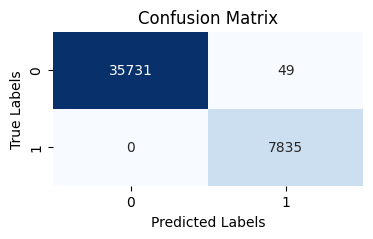

 All Hybrid IDS models saved


In [ ]:



import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, IsolationForest, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import joblib



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, "scaler.pkl")
print("✅ Scaler saved")



rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train_scaled, y_train)
y_rf_pred = rf.predict_proba(X_test_scaled)[:, 1]  # probabilities

lgb_train = lgb.Dataset(X_train_scaled, label=y_train)
lgb_test = lgb.Dataset(X_test_scaled, label=y_test, reference=lgb_train)

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

lgbm_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=300,
    valid_sets=[lgb_train, lgb_test],
    valid_names=['train','test'],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

y_lgb_pred = lgbm_model.predict(X_test_scaled, num_iteration=lgbm_model.best_iteration)


iso_forest = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=0.25,  # expected anomaly fraction
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_scaled)
y_iso_scores = iso_forest.decision_function(X_test_scaled)
y_iso_pred = iso_forest.predict(X_test_scaled)
y_iso_pred = np.where(y_iso_pred == -1, 1, 0)  # convert anomalies to attack

X_hybrid_test = np.column_stack([y_rf_pred, y_lgb_pred, y_iso_pred])
X_hybrid_train = np.column_stack([
    rf.predict_proba(X_train_scaled)[:, 1],
    lgbm_model.predict(X_train_scaled, num_iteration=lgbm_model.best_iteration),
    iso_forest.predict(X_train_scaled)
])
X_hybrid_train[:, 2] = np.where(X_hybrid_train[:, 2] == -1, 1, 0)  # convert train anomaly to 0/1

from sklearn.linear_model import LogisticRegression

meta_clf = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
meta_clf.fit(X_hybrid_train, y_train)
y_hybrid_pred = meta_clf.predict(X_hybrid_test)


accuracy = accuracy_score(y_test, y_hybrid_pred) * 100
balanced_acc = balanced_accuracy_score(y_test, y_hybrid_pred) * 100
f1 = f1_score(y_test, y_hybrid_pred) * 100

print(f" Hybrid IDS Accuracy: {accuracy:.2f}%")
print(f" Hybrid IDS Balanced Accuracy: {balanced_acc:.2f}%")
print(f" Hybrid IDS F1-Score: {f1:.2f}%\n")

print("Classification Report:\n", classification_report(y_test, y_hybrid_pred))


# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

joblib.dump(rf, "rf_supervised.pkl")
lgbm_model.save_model("lgbm_supervised.pkl")
joblib.dump(iso_forest, "iso_forest_unsupervised.pkl")
joblib.dump(meta_clf, "hybrid_meta.pkl")
print(" All Hybrid IDS models saved")


/tmp/ipython-input-3620991887.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="crest")


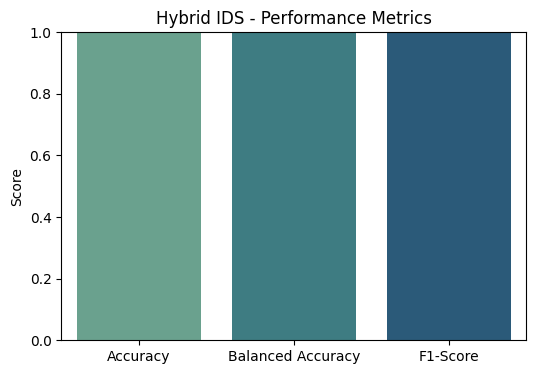

/tmp/ipython-input-3620991887.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(comparison.keys()), y=list(comparison.values()), palette="coolwarm")


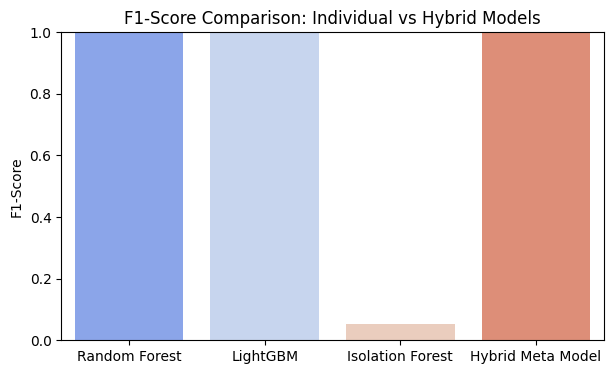

In [ ]:
# Performance Metrics
metrics = {"Accuracy": accuracy/100, "Balanced Accuracy": balanced_acc/100, "F1-Score": f1/100}
plt.figure(figsize=(6,4))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="crest")
plt.ylim(0,1)
plt.title("Hybrid IDS - Performance Metrics")
plt.ylabel("Score")
plt.show()

# Model Comparison
f1_rf = f1_score(y_test, np.where(y_rf_pred > 0.5, 1, 0))
f1_lgb = f1_score(y_test, np.where(y_lgb_pred > 0.5, 1, 0))
f1_iso = f1_score(y_test, y_iso_pred)
f1_hybrid = f1_score(y_test, y_hybrid_pred)

comparison = {
    "Random Forest": f1_rf,
    "LightGBM": f1_lgb,
    "Isolation Forest": f1_iso,
    "Hybrid Meta Model": f1_hybrid
}
plt.figure(figsize=(7,4))
sns.barplot(x=list(comparison.keys()), y=list(comparison.values()), palette="coolwarm")
plt.ylim(0,1)
plt.title("F1-Score Comparison: Individual vs Hybrid Models")
plt.ylabel("F1-Score")
plt.show()
